In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Import all the generic functions
from PEPV_Signal_Helper_Function import (
    load_and_preprocess_data,
    detect_cycles_sinusoidal, 
    detect_cycle_phases,
    Savitzky_Golay_filter,
    signal_cycles,
    custom_sigmoid_function,
    fit_custom_sigmoid_to_cycle,
    fit_sigmoid_to_all_cycles,
    create_comprehensive_cycle_dataset,
    plot_single_signal_with_cycles,
    plot_single_signal_with_sigmoid_fits,
    create_average_cycles_from_signal_cycles,
    create_average_cycle_dataset
)


In [2]:
file_path = 'Data/glycerolPG/GL_PG.csv'
# Load the CSV into a pandas DataFrame
df = pd.read_csv(file_path)

df.head()

,time_s,0.0_flow_ml_min,0.1_flow_ml_min,0.2_flow_ml_min,0.3_flow_ml_min,0.4_flow_ml_min
0,0.0,0.056,0.054,-0.076,0.076,0.049
1,0.5,0.057,0.047,-0.063,0.070,0.041
2,1.0,0.052,0.041,-0.058,0.068,0.042
3,1.5,0.048,0.048,-0.049,0.062,0.036
4,2.0,0.046,0.056,-0.045,0.054,0.029


In [3]:
# Dataset configuration
DATA_FILES = {
    "4-Roller Pump": "Data/glycerolPG/GL_PG.csv"
}

# Liquid metadata for visualization
LIQUIDS_INFO = {
    '0.0_flow_ml_min': {'name': 'Gl_PG(100-0%)', 'viscosity': '945 cP'},
    '0.1_flow_ml_min': {'name': 'Gl_PG(90-10%)', 'viscosity': '690 cP'},
    '0.2_flow_ml_min': {'name': 'GL_PG(80-20%)', 'viscosity': '520 cP'},
    '0.3_flow_ml_min': {'name': 'GL_PG(70-30%)', 'viscosity': '380 cP'},
    '0.4_flow_ml_min': {'name': 'GL_PG(60-40%)', 'viscosity': '270 cP'}
}

# Load all datasets
datasets = {}
for name, file_path in DATA_FILES.items():
    datasets[name] = load_and_preprocess_data(file_path, name)

In [18]:
cycles = signal_cycles(datasets)

Overall success: 5/5 (100.0%)
Total cycles detected: 58


Total individual signals to plot: 5


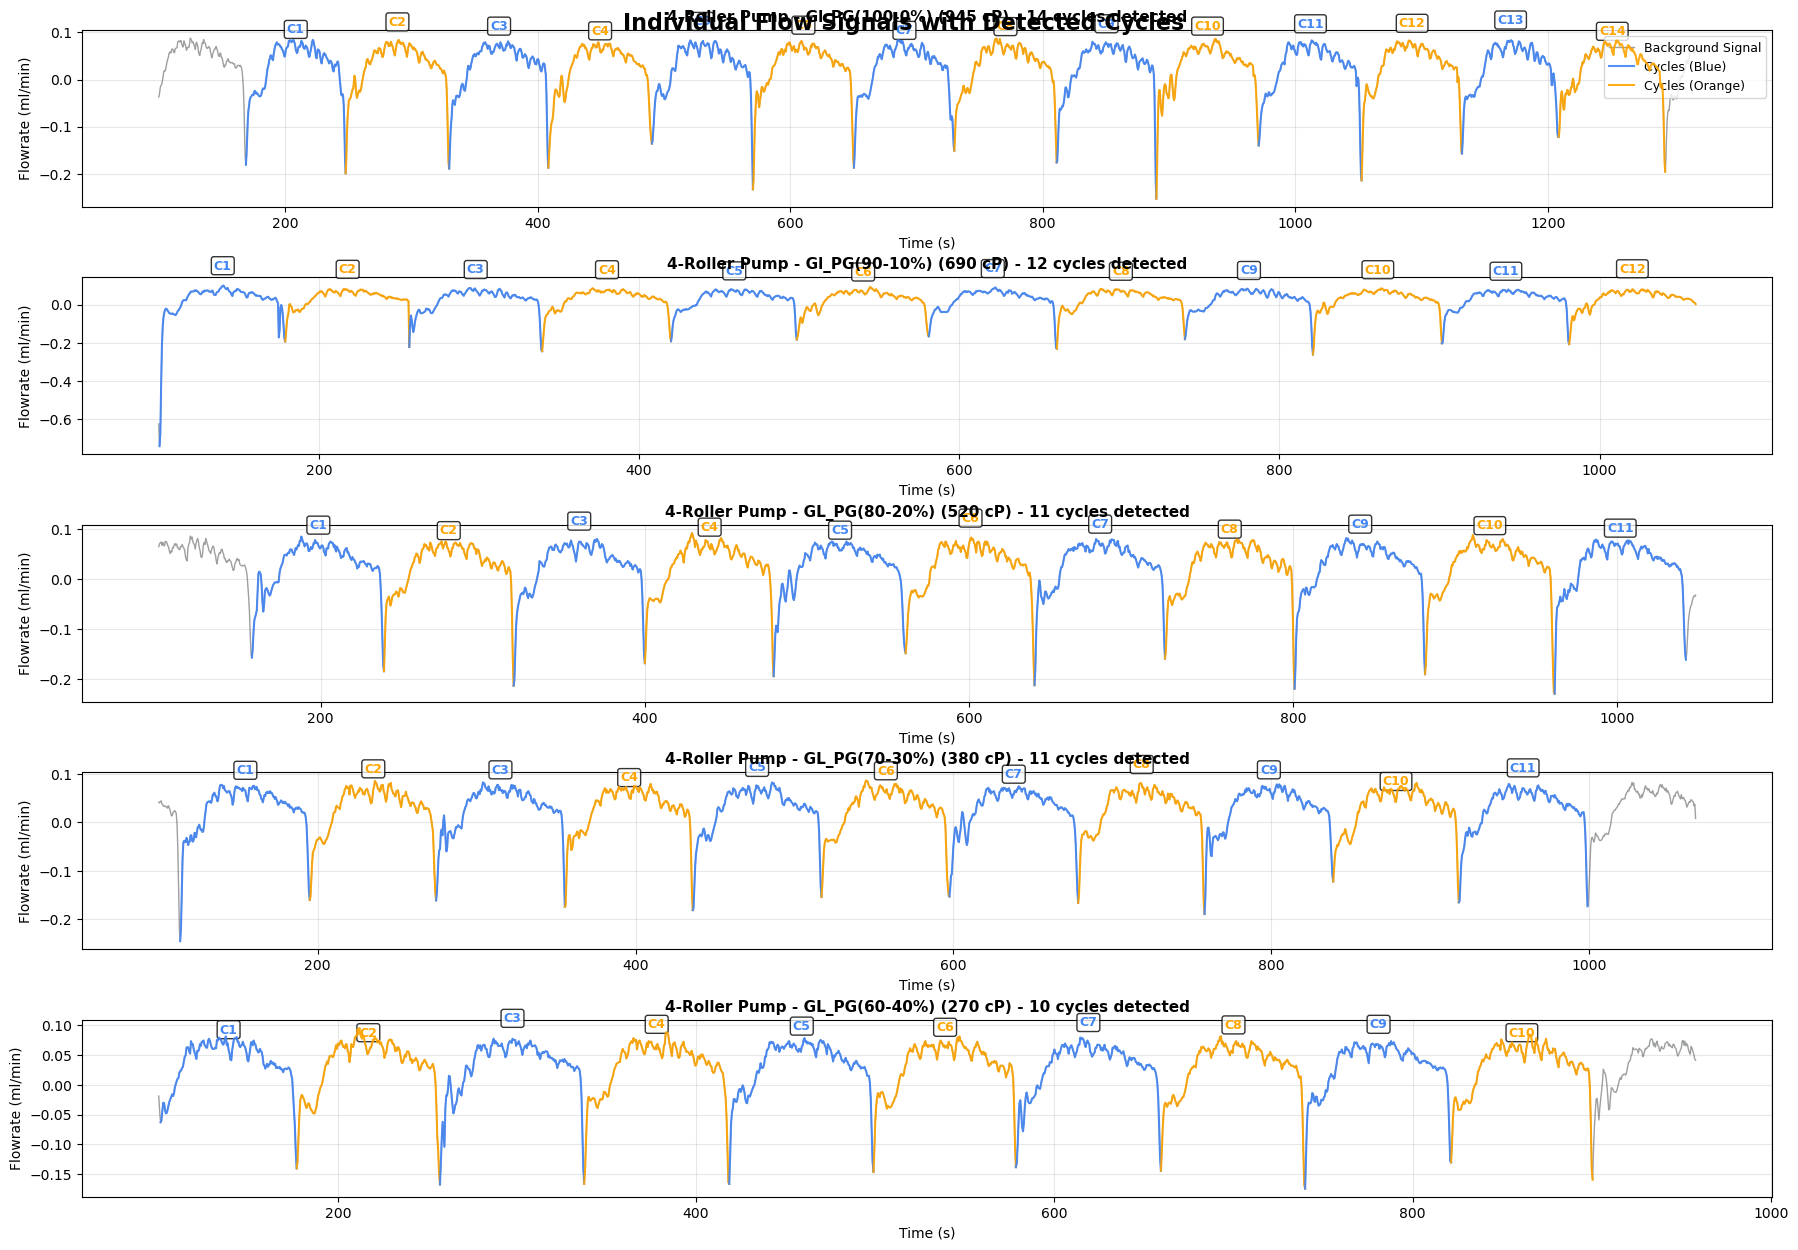

In [5]:
# Visualize every individual signal (column) from each dataset as a separate row
liquid_types = list(LIQUIDS_INFO.keys())
pump_types = list(datasets.keys())

# Create list of all individual signals
all_signals = []
for pump_type in pump_types:
    for liquid_type in liquid_types:
        if liquid_type in datasets[pump_type].columns:
            all_signals.append({
                'pump_type': pump_type,
                'liquid_type': liquid_type,
                'pump_short': pump_type.split('-')[0] + 'R',  # e.g., "2R", "3R", "4R"
                'liquid_name': liquid_type.replace('_flow_ml_min', ''),
                'display_name': f"{pump_type} - {LIQUIDS_INFO[liquid_type]['name']} ({LIQUIDS_INFO[liquid_type]['viscosity']})"
            })

num_signals = len(all_signals)
print(f"Total individual signals to plot: {num_signals}")

# Create subplot layout: one row per individual signal
fig, axes = plt.subplots(num_signals, 1, figsize=(18, 2.5 * num_signals))
fig.suptitle('Individual Flow Signals with Detected Cycles', fontsize=16, fontweight='bold', y=0.995)

# Ensure axes is always a list for consistent indexing
if num_signals == 1:
    axes = [axes]

# Use the visualization function for each signal
summary_data = []
for idx, signal_info in enumerate(all_signals):
    ax = axes[idx]
    
    pump_type = signal_info['pump_type']
    liquid_type = signal_info['liquid_type']
    
    # Get the pump data for this signal
    pump_data = datasets[pump_type]
    
    # Get liquid info from LIQUIDS_INFO
    liquid_info = LIQUIDS_INFO[liquid_type]
    
    # Extract liquid name for cycles data (generic approach)
    liquid_name = liquid_type.replace('_flow_ml_min', '')
    
    # Use the visualization function
    show_legend = (idx == 0)  # Show legend only on first subplot
    total_cycles = plot_single_signal_with_cycles(
        ax, pump_data, liquid_type, liquid_name, cycles, pump_type, liquid_info, show_legend
    )
    avg_duration = 0
    avg_amplitude = 0
    
    if (pump_type in cycles['datasets'] and 
        'liquid_results' in cycles['datasets'][pump_type] and 
        liquid_name in cycles['datasets'][pump_type]['liquid_results']):
        
        liquid_results_info = cycles['datasets'][pump_type]['liquid_results'][liquid_name]
        if 'avg_duration' in liquid_results_info:
            avg_duration = liquid_results_info['avg_duration']
        if 'avg_amplitude' in liquid_results_info:
            avg_amplitude = liquid_results_info['avg_amplitude']
    
    summary_data.append({
        'pump_type': pump_type,
        'liquid_name': liquid_info['name'],
        'viscosity': liquid_info['viscosity'],
        'cycles': total_cycles,
        'avg_duration': avg_duration,
        'avg_amplitude': avg_amplitude
    })

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(top=0.98, hspace=0.4)
plt.show()

## 1.3. Sigmoid Fitting

In [6]:
sigmoid_fit = fit_sigmoid_to_all_cycles(cycles)

   ✅ Success on attempt 2: R²=0.985, constraints satisfied
   ✅ Success on attempt 2: R²=0.982, constraints satisfied
   ✅ Success on attempt 2: R²=0.978, constraints satisfied
   📈 Overall success rate: 100.0%


c:\Users\mrast\OneDrive\Documents\GitHub\Persitaltic_Pump\Applications\Viscosity_estimation\PEPV_Signal_Helper_Function.py:617: RuntimeWarning: overflow encountered in exp
  term3 = h3 / (1 + np.exp(-(x - a3) / b3))


Total individual signals to plot with sigmoid fits: 5


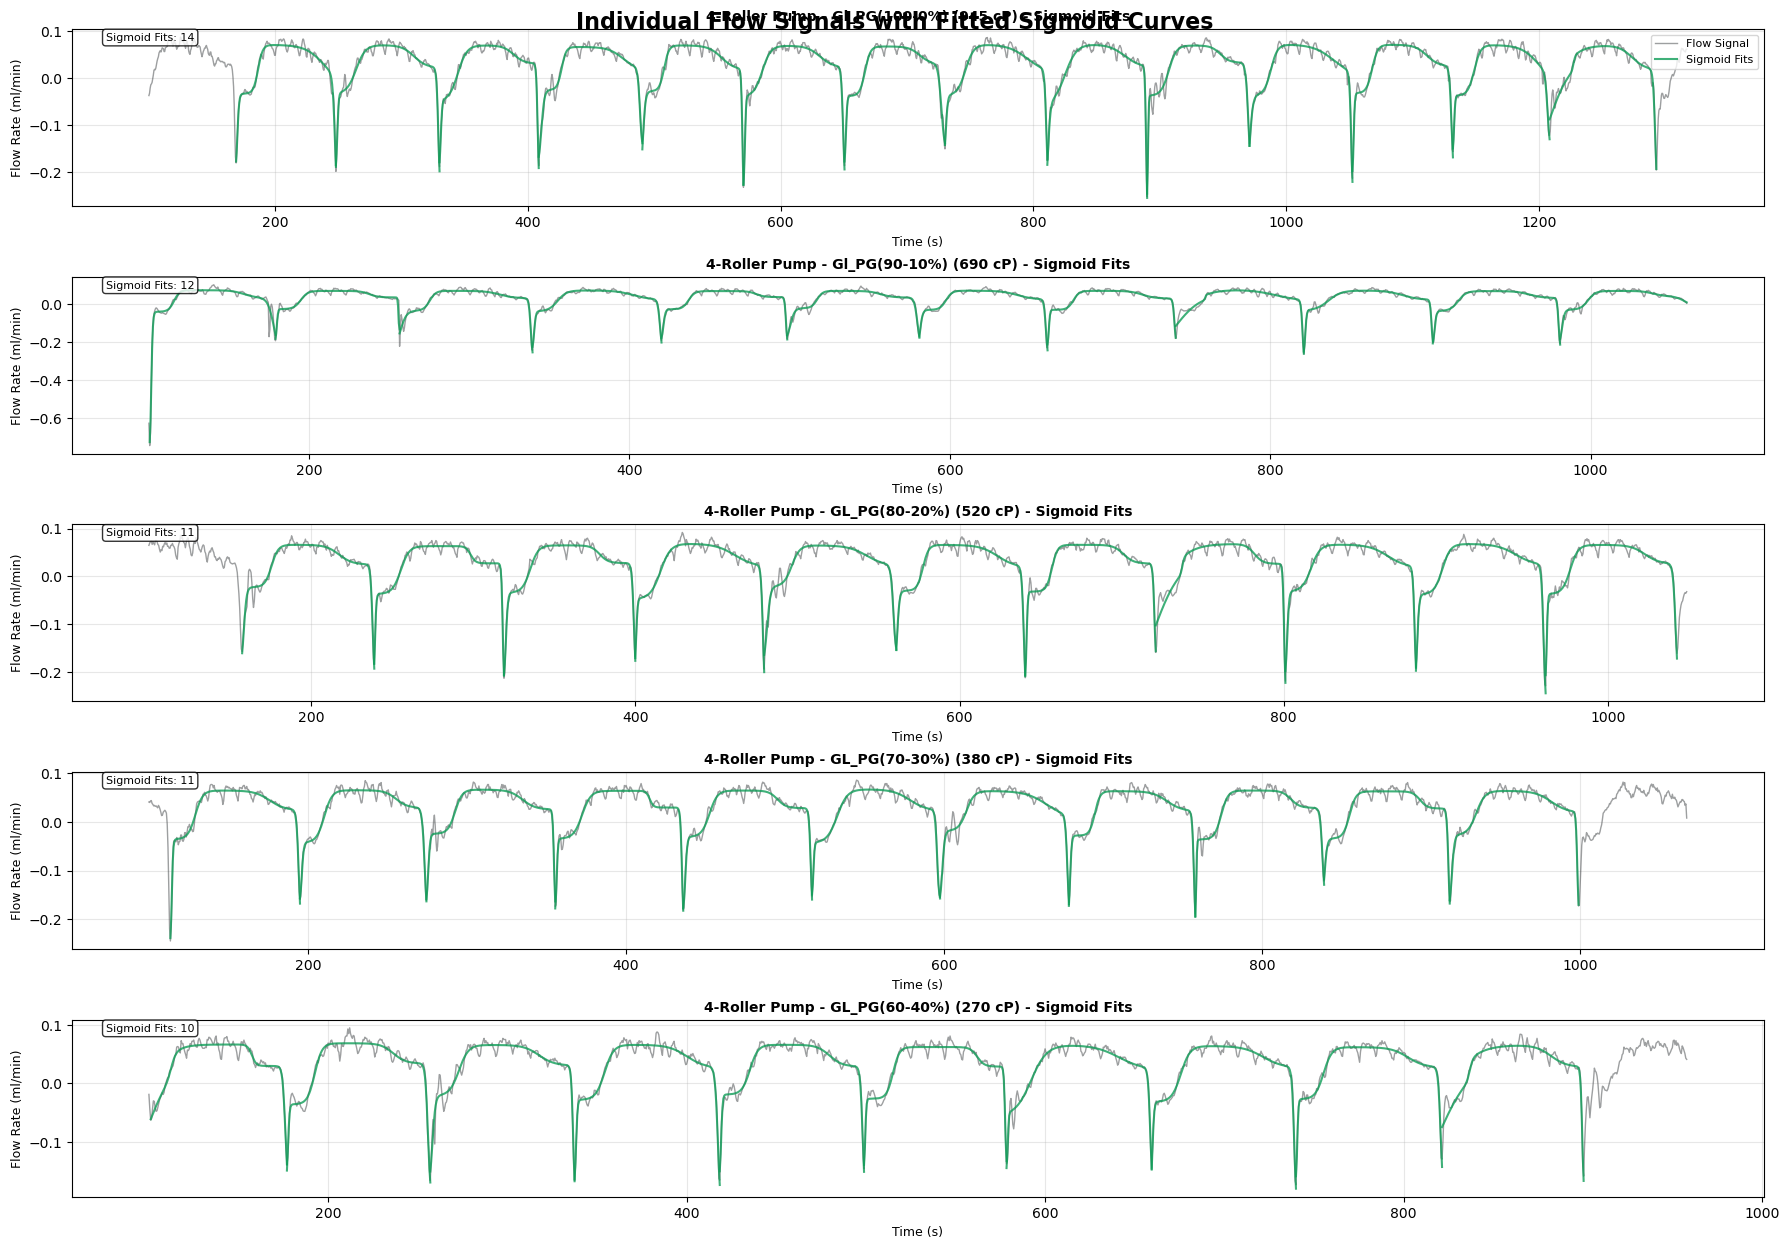

In [7]:
# Visualize sigmoid fits for all individual signals
liquid_types = list(LIQUIDS_INFO.keys())
pump_types = list(datasets.keys())

# Create list of all individual signals (reusing the same structure)
all_signals = []
for pump_type in pump_types:
    for liquid_type in liquid_types:
        if liquid_type in datasets[pump_type].columns:
            all_signals.append({
                'pump_type': pump_type,
                'liquid_type': liquid_type,
                'pump_short': pump_type.split('-')[0] + 'R',  # e.g., "2R", "3R", "4R"
                'liquid_name': liquid_type.replace('_flow_ml_min', ''),
                'display_name': f"{pump_type} - {LIQUIDS_INFO[liquid_type]['name']} ({LIQUIDS_INFO[liquid_type]['viscosity']})"
            })

num_signals = len(all_signals)
print(f"Total individual signals to plot with sigmoid fits: {num_signals}")

# Create subplot layout: one row per individual signal
fig, axes = plt.subplots(num_signals, 1, figsize=(18, 2.5 * num_signals))
fig.suptitle('Individual Flow Signals with Fitted Sigmoid Curves', fontsize=16, fontweight='bold', y=0.995)

# Ensure axes is always a list for consistent indexing
if num_signals == 1:
    axes = [axes]

# Use the sigmoid visualization function for each signal
sigmoid_summary_data = []
for idx, signal_info in enumerate(all_signals):
    ax = axes[idx]
    
    pump_type = signal_info['pump_type']
    liquid_type = signal_info['liquid_type']
    
    # Get the pump data for this signal
    pump_data = datasets[pump_type]
    
    # Get liquid info from LIQUIDS_INFO
    liquid_info = LIQUIDS_INFO[liquid_type]
    
    # Extract liquid name for cycles data (generic approach)
    liquid_name = liquid_type.replace('_flow_ml_min', '')
    
    # Use the sigmoid visualization function
    show_legend = (idx == 0)  # Show legend only on first subplot
    sigmoid_fits_count = plot_single_signal_with_sigmoid_fits(
        ax, pump_data, liquid_type, liquid_name, cycles, sigmoid_fit, pump_type, liquid_info, show_legend
    )
    
    # Collect summary data
    sigmoid_summary_data.append({
        'pump_type': pump_type,
        'liquid_name': liquid_info['name'],
        'viscosity': liquid_info['viscosity'],
        'sigmoid_fits': sigmoid_fits_count
    })

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(top=0.98, hspace=0.4)
plt.show()

## 1.4. Average Cycle

In [20]:
# Create average cycles for both pump types
average_cycles = {}

# Get the actual pump types from the datasets in cycles
if 'datasets' in cycles:
    actual_pump_types = list(cycles['datasets'].keys())
    print(f"Actual pump types found: {actual_pump_types}")
    
    for pump_type in actual_pump_types:
        pump_avg_cycles = create_average_cycles_from_signal_cycles(cycles, pump_type=pump_type, liquids_info=LIQUIDS_INFO)
        if pump_avg_cycles:  # Only add if successful
            average_cycles.update(pump_avg_cycles)
else:
    print("No 'datasets' key found in cycles data")
        
print(f"Available pump types in average_cycles: {list(average_cycles.keys())}")

Actual pump types found: ['4-Roller Pump']
  4-Roller Pump - 0.0: Created average cycle from 14 individual cycles (length: 170)
  4-Roller Pump - 0.1: Created average cycle from 12 individual cycles (length: 167)
  4-Roller Pump - 0.2: Created average cycle from 11 individual cycles (length: 164)
  4-Roller Pump - 0.3: Created average cycle from 11 individual cycles (length: 164)
  4-Roller Pump - 0.4: Created average cycle from 10 individual cycles (length: 164)
Available pump types in average_cycles: ['4-Roller Pump']


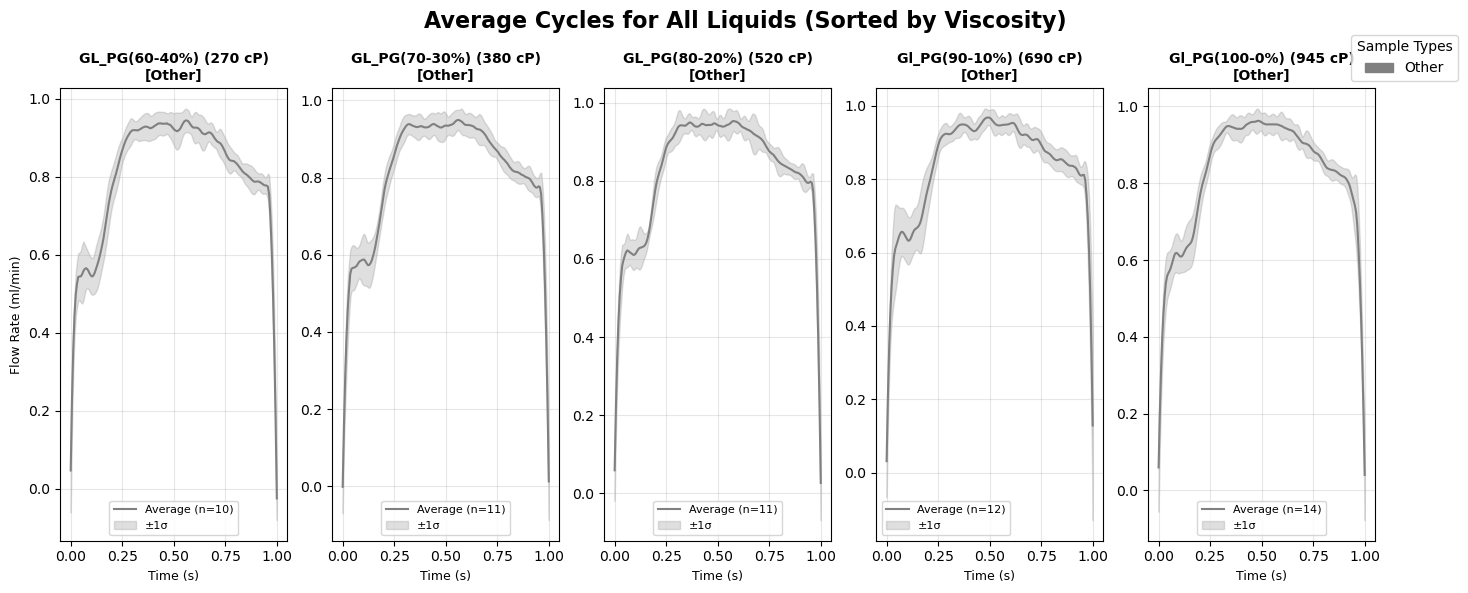

In [25]:
def visualize_average_cycles_in_row(average_cycles, liquids_info, pump_types=None):
    
    # Determine which pumps to visualize
    if pump_types is None:
        if len(average_cycles.keys()) == 0:
            print("Error: average_cycles is empty. Please check that the cycle detection worked properly.")
            return
        pump_types = list(average_cycles.keys())
    elif isinstance(pump_types, str):
        pump_types = [pump_types]
    
    # Check if all pump_types exist
    missing_pumps = [pt for pt in pump_types if pt not in average_cycles]
    if missing_pumps:
        print(f"Error: pump_type(s) {missing_pumps} not found in average_cycles.")
        print(f"Available pump types: {list(average_cycles.keys())}")
        return
    
    # Extract viscosity values for sorting
    def extract_viscosity_value(viscosity_str):
        # Extract numeric value from strings like "750 cP", "1000 cP"
        import re
        match = re.search(r'(\d+)', viscosity_str)
        return int(match.group(1)) if match else 0
    
    # Function to determine sample category based on liquid name
    def get_sample_category(liquid_name):
        if liquid_name.startswith('F'):
            return 'Factory'
        elif liquid_name.startswith('si'):
            return 'Lab_mixed'
        else:
            return 'Other'
    
    # Create signal info for all pump types and combine them
    all_cycle_signals = []
    for pump_type in pump_types:
        pump_cycles = average_cycles[pump_type]
        available_liquids = list(pump_cycles.keys())
        
        for liquid_name in available_liquids:
            # Find corresponding liquid type key
            liquid_type = None
            for lt in liquids_info.keys():
                if lt.replace('_flow_ml_min', '') == liquid_name:
                    liquid_type = lt
                    break
            
            if liquid_type and liquid_type in liquids_info:
                sample_category = get_sample_category(liquid_name)
                all_cycle_signals.append({
                    'pump_type': pump_type,
                    'liquid_name': liquid_name,
                    'liquid_type': liquid_type,
                    'sample_category': sample_category,
                    'display_name': f"{liquids_info[liquid_type]['name']} ({liquids_info[liquid_type]['viscosity']})",
                    'viscosity_value': extract_viscosity_value(liquids_info[liquid_type]['viscosity'])
                })
    
    # Sort all signals by viscosity value across all pump types
    all_cycle_signals.sort(key=lambda x: x['viscosity_value'])
    
    num_signals = len(all_cycle_signals)
    
    if num_signals == 0:
        print("No matching liquid types found for visualization.")
        return
    
    # Define colors for different sample categories
    sample_colors = {
        'Factory': 'blue',
        'Lab_mixed': 'red',
        'Other': 'gray'
    }
    
    # Create horizontal subplot layout (1 row, multiple columns)
    fig, axes = plt.subplots(1, num_signals, figsize=(3 * num_signals, 6))
    fig.suptitle('Average Cycles for All Liquids (Sorted by Viscosity)', fontsize=16, fontweight='bold')
    
    # Ensure axes is always a list for consistent indexing
    if num_signals == 1:
        axes = [axes]
    
    # Plot all signals in viscosity order
    for idx, signal_info in enumerate(all_cycle_signals):
        ax = axes[idx]
        
        pump_type = signal_info['pump_type']
        liquid_name = signal_info['liquid_name']
        liquid_type = signal_info['liquid_type']
        sample_category = signal_info['sample_category']
        
        # Get the average cycle data
        pump_cycles = average_cycles[pump_type]
        avg_data = pump_cycles[liquid_name]
        avg_flow = avg_data['avg_flow']
        avg_time = avg_data['avg_time']
        flow_std = avg_data['flow_std']
        num_cycles = avg_data['num_cycles']
        
        # Get color for this sample category
        color = sample_colors.get(sample_category, 'black')
        
        # Plot the average cycle with error bands
        ax.plot(avg_time, avg_flow, color=color, linewidth=1.5, 
               label=f'Average (n={num_cycles})')
        ax.fill_between(avg_time, avg_flow - flow_std, avg_flow + flow_std, 
                       alpha=0.25, color=color, label='±1σ')
        
        # Formatting
        pump_label = pump_type.replace('_', ' ').title()
        ax.set_title(f"{signal_info['display_name']}\n[{sample_category}]", 
                    fontweight='bold', fontsize=10)
        ax.set_xlabel('Time (s)', fontsize=9)
        if idx == 0:  # Only show ylabel on leftmost plot
            ax.set_ylabel('Flow Rate (ml/min)', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    
    # Create a custom legend for sample categories
    import matplotlib.patches as mpatches
    legend_patches = []
    # Get unique sample categories from the data
    unique_categories = set(signal['sample_category'] for signal in all_cycle_signals)
    for category in sorted(unique_categories):
        color = sample_colors.get(category, 'black')
        legend_patches.append(mpatches.Patch(color=color, label=category))
    
    fig.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(0.98, 0.95), 
              title='Sample Types', fontsize=10)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.85, right=0.92)
    plt.show()

# Visualize both pump types with liquids ordered by viscosity
visualize_average_cycles_in_row(average_cycles, LIQUIDS_INFO)


## 1.5. Sigmoid Fitting on Average Cycles

In [10]:
# Apply sigmoid fitting to the average cycles
def fit_sigmoid_to_average_cycles(average_cycles_data, liquids_info):
    
    sigmoid_results = {}
    
    for pump_type, pump_cycles in average_cycles_data.items():
        sigmoid_results[pump_type] = {}
        
        for liquid_name, cycle_data in pump_cycles.items():
            try:
                # Extract average cycle data
                avg_flow = cycle_data['avg_flow']
                avg_time = cycle_data['avg_time']
                
                # Create a cycle-like data structure that fit_custom_sigmoid_to_cycle expects
                cycle_structure = {
                    'cycle_time': avg_time,
                    'cycle_flow': avg_flow,
                    'original_cycle_time': avg_time,  # Same as cycle_time for average cycles
                    'original_cycle_flow': avg_flow   # Same as cycle_flow for average cycles
                }
                
                # Use the existing detect_cycle_phases function to get proper phase boundaries
                # This uses the same logic as in the helper function, avoiding duplication
                phases = detect_cycle_phases(cycle_structure, phase1_percent=15, phase4_percent=10)
                if phases:
                    cycle_structure['phases'] = phases
                
                # Apply sigmoid fitting to the average cycle
                sigmoid_result = fit_custom_sigmoid_to_cycle(cycle_structure)
                
                if sigmoid_result and sigmoid_result.get('success', False):
                    # Calculate RMSE from fitted values
                    fitted_values = sigmoid_result['fitted_values']
                    rmse = np.sqrt(np.mean((avg_flow - fitted_values)**2))
                    
                    sigmoid_results[pump_type][liquid_name] = {
                        'sigmoid_params': sigmoid_result['fitted_params'],
                        'fitted_curve': fitted_values,
                        'r_squared': sigmoid_result['r_squared'],
                        'rmse': rmse,
                        'time_points': avg_time,
                        'original_flow': avg_flow,
                        'success': True,
                        'num_original_cycles': cycle_data['num_cycles']
                    }
                    
                    # Get viscosity info
                    liquid_type = None
                    for lt in liquids_info.keys():
                        if lt.replace('_flow_ml_min', '') == liquid_name:
                            liquid_type = lt
                            break
                    
                    viscosity = liquids_info[liquid_type]['viscosity'] if liquid_type else 'Unknown'
                    
                    print(f"  {liquid_name} ({viscosity}): R²={sigmoid_result['r_squared']:.4f}, RMSE={rmse:.4f}")
                else:
                    sigmoid_results[pump_type][liquid_name] = {
                        'success': False,
                        'num_original_cycles': cycle_data['num_cycles']
                    }
                    print(f"  {liquid_name}: Sigmoid fitting failed")
                    
            except Exception as e:
                sigmoid_results[pump_type][liquid_name] = {
                    'success': False,
                    'error': str(e),
                    'num_original_cycles': cycle_data['num_cycles']
                }
                print(f"  {liquid_name}: Error during fitting - {str(e)}")
    
    return sigmoid_results

In [21]:
# Apply sigmoid fitting to average cycles
average_sigmoid_results = fit_sigmoid_to_average_cycles(average_cycles, LIQUIDS_INFO)

   ✅ Success on attempt 2: R²=0.997, constraints satisfied
  0.0 (945 cP): R²=0.9971, RMSE=0.0097
  0.1 (690 cP): R²=0.9947, RMSE=0.0117
  0.2 (520 cP): R²=0.9973, RMSE=0.0089
  0.3 (380 cP): R²=0.9969, RMSE=0.0101
  0.4 (270 cP): R²=0.9975, RMSE=0.0089


In [12]:
def visualize_average_cycles_with_sigmoid(average_cycles_data, sigmoid_results, liquids_info, pump_type=None):

    pump_cycles = average_cycles_data[pump_type]
    pump_sigmoids = sigmoid_results[pump_type]
    available_liquids = list(pump_cycles.keys())
    
    # Create signal info for plotting
    cycle_signals = []
    for liquid_name in available_liquids:
        # Find corresponding liquid type key
        liquid_type = None
        for lt in liquids_info.keys():
            if lt.replace('_flow_ml_min', '') == liquid_name:
                liquid_type = lt
                break
        
        if liquid_type and liquids_info:
            cycle_signals.append({
                'liquid_name': liquid_name,
                'liquid_type': liquid_type,
                'display_name': f"{liquids_info[liquid_type]['name']} ({liquids_info[liquid_type]['viscosity']})"
            })
    
    num_signals = len(cycle_signals)
        
    # Create horizontal subplot layout
    fig, axes = plt.subplots(1, num_signals, figsize=(4 * num_signals, 6))
    fig.suptitle(f'{pump_type} - Average Cycles with Sigmoid Fits', fontsize=16, fontweight='bold')
    
    # Ensure axes is always a list for consistent indexing
    if num_signals == 1:
        axes = [axes]
    
    successful_fits = 0
    
    for idx, signal_info in enumerate(cycle_signals):
        ax = axes[idx]
        
        liquid_name = signal_info['liquid_name']
        liquid_type = signal_info['liquid_type']
        
        # Get the average cycle data
        avg_data = pump_cycles[liquid_name]
        avg_flow = avg_data['avg_flow']
        avg_time = avg_data['avg_time']
        flow_std = avg_data['flow_std']
        num_cycles = avg_data['num_cycles']
        
        # Plot the average cycle with error bands
        ax.plot(avg_time, avg_flow, 'b-', linewidth=2.5, alpha=0.7, label=f'Average (n={num_cycles})')
        ax.fill_between(avg_time, avg_flow - flow_std, avg_flow + flow_std, 
                       alpha=0.15, color='blue')
        
        # Plot sigmoid fit if successful
        sigmoid_data = pump_sigmoids[liquid_name]
        if sigmoid_data.get('success', False):
            fitted_curve = sigmoid_data['fitted_curve']
            r_squared = sigmoid_data['r_squared']
            ax.plot(avg_time, fitted_curve, 'r--', linewidth=2, 
                   label=f'Sigmoid Fit (R²={r_squared:.3f})')
            successful_fits += 1
        else:
            ax.text(0.5, 0.5, 'Fit Failed', transform=ax.transAxes, 
                   ha='center', va='center', fontsize=12, color='red',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
        
        # Formatting
        ax.set_title(signal_info['display_name'], fontweight='bold', fontsize=12)
        ax.set_xlabel('Time (s)', fontsize=11)
        if idx == 0:  # Only show ylabel on leftmost plot
            ax.set_ylabel('Flow Rate (ml/min)', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        
        # Add statistics
        if sigmoid_data.get('success', False):
            rmse = sigmoid_data['rmse']
            stats_text = (f"RMSE: {rmse:.4f}\n"
                         f"R²: {r_squared:.4f}")
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=9, 
                    verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()
    
    # Print summary
    print(f"Successfully fitted: {successful_fits}/{num_signals} average cycles")
    print(f"{'Liquid':<8} {'Viscosity':<10} {'R²':<8} {'RMSE':<10} {'Status':<10}")
    print("-" * 60)
    
    for liquid_name in available_liquids:
        sigmoid_data = pump_sigmoids[liquid_name]
        liquid_type = None
        for lt in liquids_info.keys():
            if lt.replace('_flow_ml_min', '') == liquid_name:
                liquid_type = lt
                break
        
        if liquid_type:
            viscosity = liquids_info[liquid_type]['viscosity']
            if sigmoid_data.get('success', False):
                r_squared = sigmoid_data['r_squared']
                rmse = sigmoid_data['rmse']
                status = "Success"
                print(f"{liquid_name:<8} {viscosity:<10} {r_squared:<8.4f} {rmse:<10.4f} {status:<10}")
            else:
                print(f"{liquid_name:<8} {viscosity:<10} {'N/A':<8} {'N/A':<10} {'Failed':<10}")


In [22]:
# Create the average cycle dataset
avg_df = create_average_cycle_dataset(average_cycles, average_sigmoid_results, LIQUIDS_INFO)


📊 AVERAGE CYCLE DATASET CREATION SUMMARY:
   🎯 Total average cycles: 5
   📈 Unique samples: 5
   🔧 Unique pump types: 1
   📈 All average cycles have sigmoid fits


In [23]:
print(f"Average cycle dataset shape: {avg_df.shape}")

avg_df

Average cycle dataset shape: (5, 22)


,sample_name,pump_type,num_original_cycles,a1,a2,a3,a4,h1,h2,h3,...,b2,b3,b4,r_squared,rmse,duration_sec,flow_max_ml_min,flow_min_ml_min,flow_std_avg,viscosity_cp
0,0.0,4-Roller Pump,14,0.013715,0.206075,0.793052,0.989761,0.543769,0.373003,-0.189749,...,0.035419,0.077571,0.011262,0.997099,0.009652,1.0,0.962437,0.040359,0.036980,945.0
1,0.1,4-Roller Pump,12,0.013473,0.207854,0.766132,0.990000,0.599629,0.319261,-0.132331,...,0.030550,0.061152,0.007515,0.994717,0.011748,1.0,0.968250,0.030968,0.044465,690.0
2,0.2,4-Roller Pump,11,0.012031,0.202134,0.759269,0.990000,0.577268,0.342230,-0.140086,...,0.029767,0.051370,0.008591,0.997283,0.008891,1.0,0.953588,0.025923,0.032710,520.0
3,0.3,4-Roller Pump,11,0.013347,0.202631,0.761351,0.990000,0.562779,0.376308,-0.150664,...,0.030400,0.047592,0.008547,0.996872,0.010136,1.0,0.949274,-0.001217,0.037622,380.0
4,0.4,4-Roller Pump,10,0.008314,0.190910,0.768531,0.989684,0.559459,0.396440,-0.155037,...,0.032900,0.053831,0.008270,0.997471,0.008933,1.0,0.943751,-0.025150,0.038927,270.0


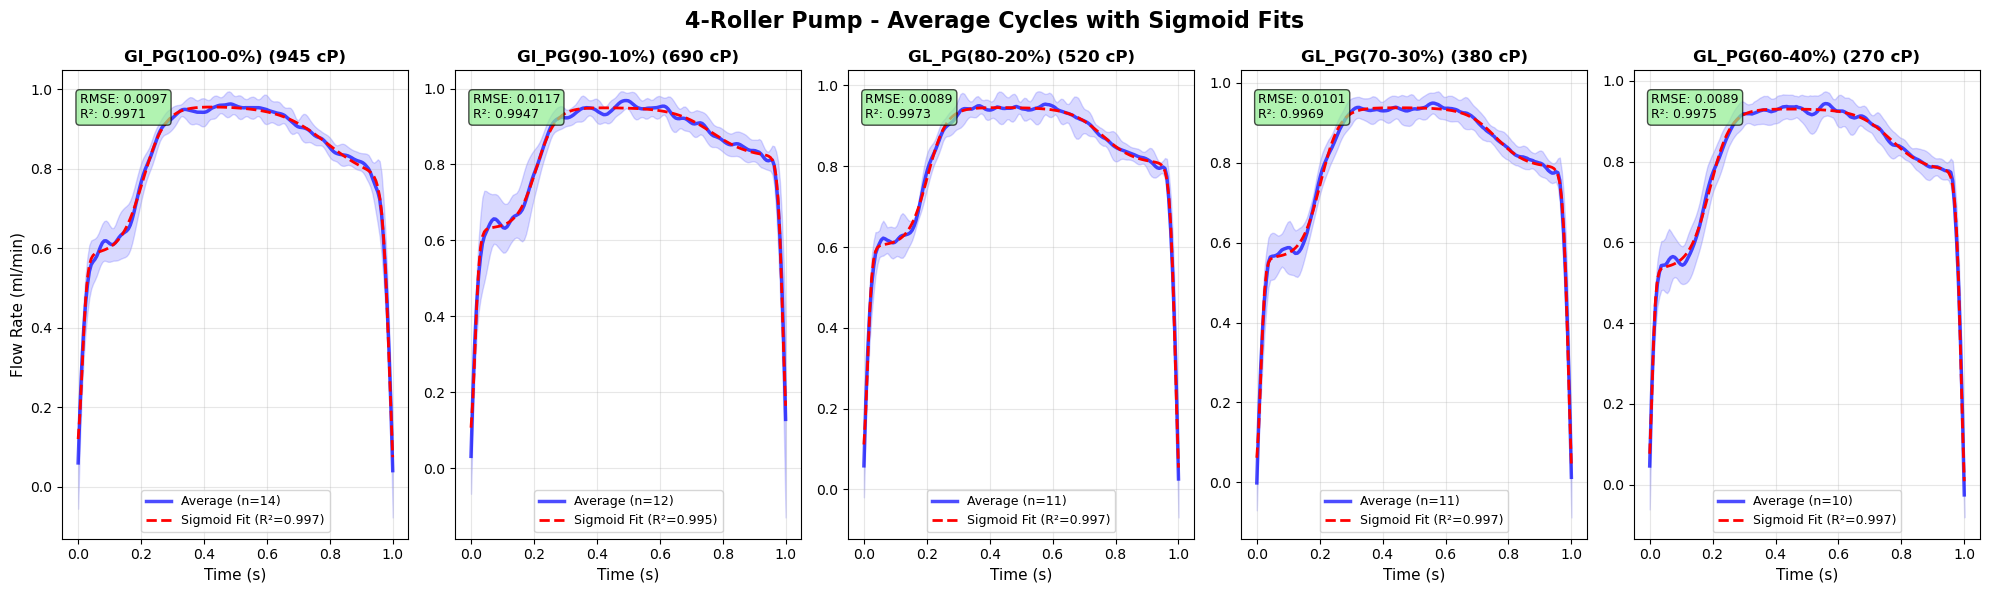

Successfully fitted: 5/5 average cycles
Liquid   Viscosity  R²       RMSE       Status    
------------------------------------------------------------
0.0      945 cP     0.9971   0.0097     Success   
0.1      690 cP     0.9947   0.0117     Success   
0.2      520 cP     0.9973   0.0089     Success   
0.3      380 cP     0.9969   0.0101     Success   
0.4      270 cP     0.9975   0.0089     Success   


In [24]:
# Visualize the average cycles with sigmoid fits
visualize_average_cycles_with_sigmoid(average_cycles, average_sigmoid_results, LIQUIDS_INFO, pump_type='4-Roller Pump')